In [13]:
from typing import Dict, List, Any
from numpy.typing import NDArray

from model_ranking import (
    get_summary_results, 
    per_source_model_results,
    cmb_consistency_score_weighted_average,
    to_target_transfer_correlations_with_norm,
    correlation_table,
    per_target_consis_result_type,
    per_target_performance_result_type,
)
from model_ranking import plot_alpha_sweep_specific_norm

In [14]:
NA_UNet_source_models = {
    # "EPFL": "E_model_NA2",
    "Hmito": "HtoE_def_Hm_model_NA2",
    "Rmito": "RtoE_def_Rm_model_NA2",
    "VNC": "VtoE_def_V_model_NA2_2",
}
Res_source_models = {
    # "EPFL": "E_model_Res1",
    "Hmito": "HtoE_def_Hm_model_Res1",
    "Rmito": "RtoE_def_Rm_model_Res1",
    "VNC": "VtoE_def_V_model_Res1",
}

Unetr_source_models = {
    # "EPFL": "E_model_Unetr2",
    "Hmito": "HtoE_def_Hm_model_Unetr2",
    "Rmito": "RtoE_def_Rm_model_Unetr2",
}
Unet_source_models={
    # "EPFL": "E_model5",
    "Hmito": "HtoE_def_Hm_model4_2",
    "Rmito": "RtoE_def_Rm_model4",
    "VNC": "VtoE_def_V_model2",
}
consis_keys={
    "EPFL": "EI_consis",
    "Hmito": "EI_consis",
    "Rmito": "EI_consis",
    "VNC": "EI_consis",
}
consis_keys_bckg = {
    "EPFL": "EI_consis_bckg",
    "Hmito": "EI_consis_bckg",
    "Rmito": "EI_consis_bckg",
    "VNC": "EI_consis_bckg",
}
result_folders={
    "EPFL": "finetuned",
    # "Hmito": "P_full",
    # "Rmito": "P_full",
    # "VNC": "P_full",
}

per_target_norms: Dict[str, List[str]] = {
    "EPFL": ["Normalize"],
    "Hmito": ["Normalize"],
    "Rmito": ["Normalize"],
    "VNC": ["Normalize"],
}

perf_key = "F1_eval"
approach="consistency"
base_result_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"

In [3]:
summary_results_postfix = "_full"
selected_augmentations = {
    "none": [""],
    "gauss": ["a001-003", "a003-005", "a005-007", "a007-01", "a01-012", "a012-015", "a015-02"],
}
#targets = ["EPFL", "Hmito", "Rmito", "VNC"]
targets = ["EPFL"]
source_model_types = [NA_UNet_source_models, Res_source_models, Unet_source_models, Unetr_source_models]

In [4]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["Hmito", "Rmito"]
    else:
        sources = ["Hmito", "Rmito", "VNC"]
    per_source_forg_consistency = {}
    per_source_forg_performance = {}

    for model_type in source_model_types:
        if "Unetr" in model_type["Hmito"]:
            sources = ["Hmito", "Rmito"] 
            
        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_forg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_forg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
    
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 15.17it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 16.32it/s]


Source: VNC


...

100%|██████████| 1/1 [00:00<00:00, 19.74it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00,  6.18it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00,  8.50it/s]


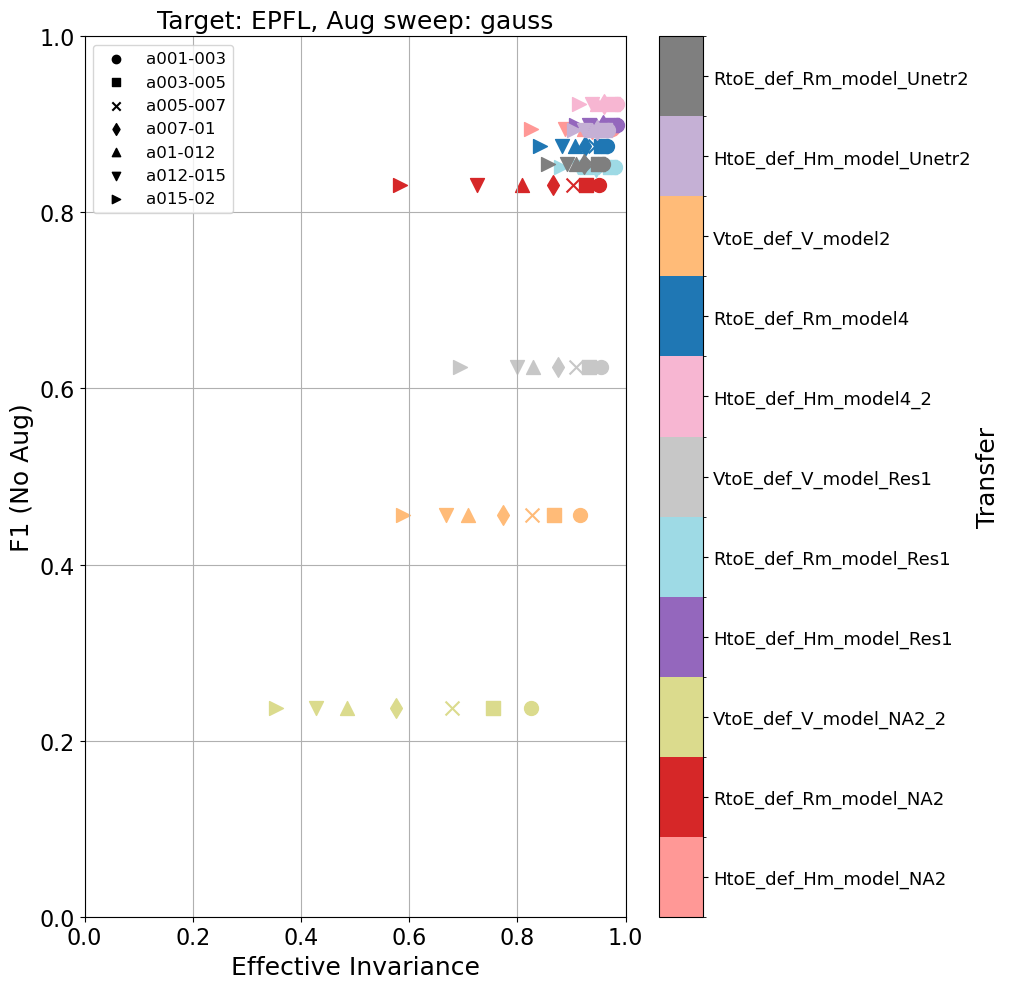

In [5]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

In [6]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_forg_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
    perturbation_key="gauss"
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

gauss: a001-003
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.93      0.0   0.89        0.01  0.78      0.0
gauss: a003-005
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.95      0.0    0.9         0.0  0.82      0.0
gauss: a005-007
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.96      0.0   0.89         0.0  0.78      0.0
gauss: a007-01
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.96      0.0   0.92         0.0  0.82      0.0
gauss: a01-012
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.96      0.0   0.91         0.0  0.78  

In [7]:
per_target_bckg_consistency: Dict[str, Dict[str, Dict[str, Dict[str, NDArray[Any]]]]] = {}
per_target_bckg_performance: Dict[str, Dict[str, Dict[str, NDArray[Any]]]] = {}

for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["Hmito", "Rmito"]
    else:
        sources = ["Hmito", "Rmito", "VNC"]
    per_source_bckg_consistency = {}
    per_source_bckg_performance = {}

    for model_type in source_model_types:
        if "Unetr" in model_type["Hmito"]:
            sources = ["Hmito", "Rmito"]

        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys_bckg,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_bckg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_bckg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
        
    
    per_target_bckg_consistency[target] = per_source_bckg_consistency
    per_target_bckg_performance[target] = per_source_bckg_performance

    

Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 25.08it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 21.80it/s]


Source: VNC


...

100%|██████████| 1/1 [00:00<00:00, 18.54it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 20.22it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 18.53it/s]


In [8]:
per_target_cmb_consistency = cmb_consistency_score_weighted_average(
    per_target_forg_consistency,
    per_target_bckg_consistency,
    w_fg=0.5,
    w_bg=0.5,
    perturbation_key="gauss",
)

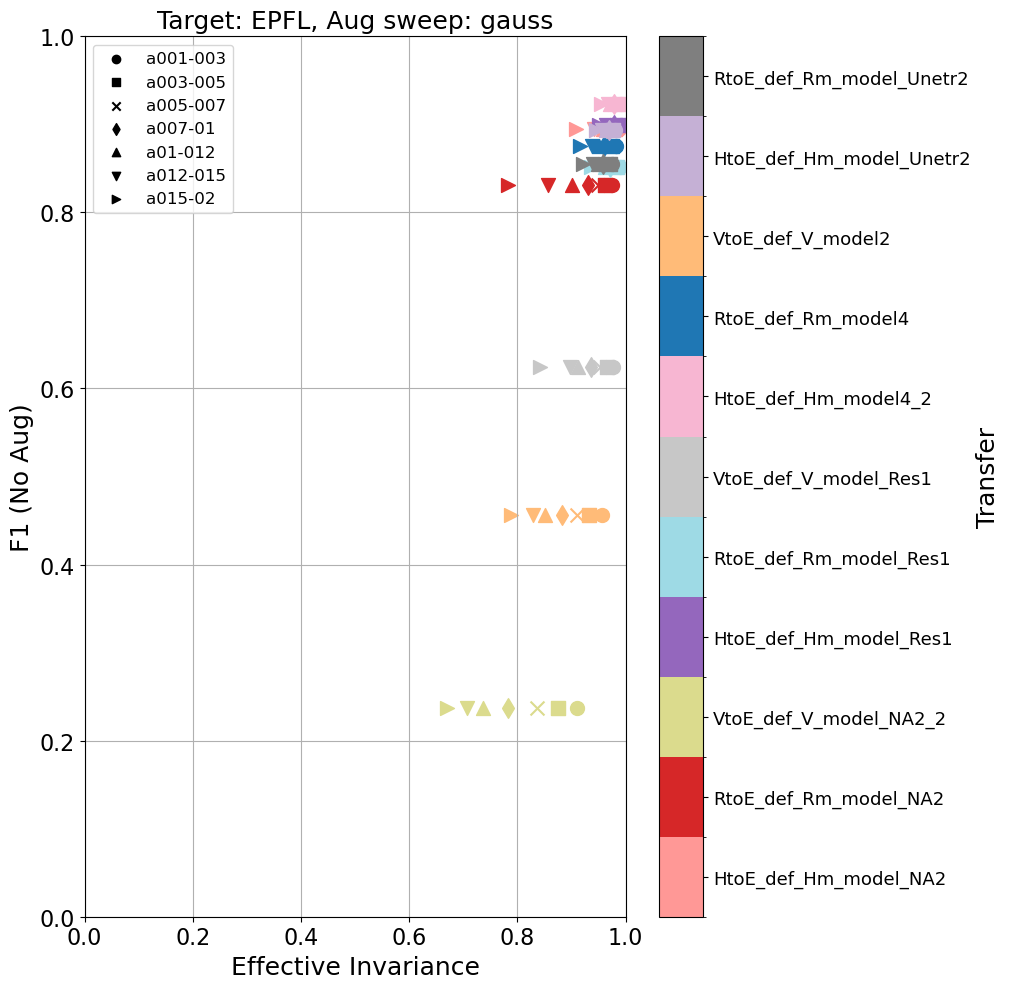

In [9]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_cmb_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

In [12]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_cmb_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
    perturbation_key="gauss"
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

gauss: a001-003
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.93      0.0   0.85         0.0  0.71      0.0
gauss: a003-005
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.95      0.0    0.9         0.0  0.82      0.0
gauss: a005-007
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.96      0.0    0.9         0.0  0.82      0.0
gauss: a007-01
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.96      0.0   0.89         0.0  0.78      0.0
gauss: a01-012
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.96      0.0   0.92         0.0  0.82  

# Save Results

In [11]:
per_target_consistency_a001_a003: Dict[str, Dict[str,float]] = {}
per_target_consistency_a003_a005: Dict[str, Dict[str,float]] = {}
per_target_consistency_a005_a007: Dict[str, Dict[str,float]] = {}
per_target_consistency_a007_a01: Dict[str, Dict[str,float]] = {}
per_target_consistency_a01_a012: Dict[str, Dict[str,float]] = {}
per_target_consistency_a012_a015: Dict[str, Dict[str,float]] = {}
per_target_consistency_a015_a02: Dict[str, Dict[str,float]] = {}
for target, per_model_consistency in per_target_cmb_consistency.items():
    per_target_consistency_a001_a003[target] = {}
    per_target_consistency_a003_a005[target] = {}
    per_target_consistency_a005_a007[target] = {}
    per_target_consistency_a007_a01[target] = {}
    per_target_consistency_a01_a012[target] = {}
    per_target_consistency_a012_a015[target] = {}
    per_target_consistency_a015_a02[target] = {}
    for model, consistency in per_model_consistency.items():
        per_target_consistency_a001_a003[target][model] = consistency['norm_Normalize']['gauss'][0]
        per_target_consistency_a003_a005[target][model] = consistency['norm_Normalize']['gauss'][1]
        per_target_consistency_a005_a007[target][model] = consistency['norm_Normalize']['gauss'][2]
        per_target_consistency_a007_a01[target][model] = consistency['norm_Normalize']['gauss'][3]
        per_target_consistency_a01_a012[target][model] = consistency['norm_Normalize']['gauss'][4]
        per_target_consistency_a012_a015[target][model] = consistency['norm_Normalize']['gauss'][5]
        per_target_consistency_a015_a02[target][model] = consistency['norm_Normalize']['gauss'][6]


In [15]:
per_target_performance: Dict[str, Dict[str,float]] = {}
for target, per_model_performance in per_target_forg_performance.items():
    per_target_performance[target] = {}
    for model, performance in per_model_performance.items():
        if isinstance(performance, dict):
            per_target_performance[target][model] = performance['norm_Normalize']
        else:
            per_target_performance[target][model] = performance


In [ ]:
# import json
# import os
# from model_ranking import convert_numpy_types
# save_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/self_supervised"
# if not os.path.exists(save_path):
#     os.makedirs(save_path)
# with open(os.path.join(save_path, "transfer_self_supervised_finetuned_performance_scores_with_NORM.json"), "w") as f:
#     results: Dict[str, Any] = {
#         "performance_scores": convert_numpy_types(per_target_forg_performance),
#     }
#     json.dump(results, f, indent=4)